# Análisis Exploratorio de Datos (EDA)

## Introducción

Este documento presenta un análisis exploratorio del archivo **data_2017_2022 1(in).csv**, que recopila mediciones de diversas variables ambientales en la ciudad de Cali (Colombia) entre 2017 y 2022. El conjunto incluye contaminantes criterio —material particulado fino (PM2.5), material particulado (PM10), ozono (O3) y dióxido de azufre (SO2)— junto con variables meteorológicas como temperatura, humedad, lluvia, presión, viento y radiación solar, registradas en varias estaciones de monitoreo.

El objetivo del EDA es caracterizar la calidad del aire en Cali, **detectar zonas y periodos con concentraciones no saludables** y aportar evidencia para **diseñar un posible plan de acción** (priorización de estaciones, contaminantes y épocas). Se toman como referencia los límites recomendados por la OMS. El análisis se aborda desde múltiples ángulos —distribuciones, superación de umbrales, comparación entre estaciones, evolución temporal, correlaciones y patrones espaciales— mediante tablas, diversos tipos de gráficas y su interpretación en prosa.

## 1.1. Carga de datos y configuración

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

def etiquetar_barras(ax, vertical=True, fmt='.1f'):
    """Añade el valor numérico centrado en la parte superior de cada barra."""
    for bar in ax.patches:
        if vertical:
            h = bar.get_height()
            if not np.isnan(h) and h != 0:
                ax.text(bar.get_x() + bar.get_width()/2., h, format(h, fmt),
                        ha='center', va='bottom', fontsize=9, fontweight='medium')
        else:
            w = bar.get_width()
            if not np.isnan(w) and w != 0:
                ax.text(w, bar.get_y() + bar.get_height()/2., format(w, fmt),
                        ha='left', va='center', fontsize=9, fontweight='medium')

In [19]:
ruta = 'data_2017_2022 1(in).csv'
df = pd.read_csv(ruta, sep=';', low_memory=False, na_values=['NA', ''])
# Decimal con coma en 'medicion'
df['medicion'] = df['medicion'].astype(str).str.replace(',', '.', regex=False)
df['medicion'] = pd.to_numeric(df['medicion'], errors='coerce')
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
df.head(10)

,fecha,estacion,variable,tipo,medicion
0,2017-01-01 00:59:59+00:00,base_aerea,pm25,val,NaN
1,2017-01-01 00:59:59+00:00,base_aerea,so2,val,NaN
2,2017-01-01 00:59:59+00:00,base_aerea,lluvia,val,NaN
3,2017-01-01 00:59:59+00:00,base_aerea,o3,val,NaN
4,2017-01-01 00:59:59+00:00,base_aerea,temperatura,val,NaN
5,2017-01-01 00:59:59+00:00,compartir,pm25,val,161.000000
6,2017-01-01 00:59:59+00:00,compartir,o3,val,8.456252
7,2017-01-01 00:59:59+00:00,compartir,pm10,val,221.000000
8,2017-01-01 00:59:59+00:00,compartir,temperatura,val,25.300000
9,2017-01-01 00:59:59+00:00,compartir,humedad,val,75.900000


## 1.2. Estructura del dataset

In [20]:
print('Dimensiones:', df.shape)
print('\nColumnas:', df.columns.tolist())
print('\nRango de fechas:', df['fecha'].min(), 'a', df['fecha'].max())
print('\nVariables (contaminantes y meteorológicas):')
print(df['variable'].value_counts())
print('\nEstaciones de monitoreo:')
print(df['estacion'].value_counts())

Dimensiones: (1048575, 5)

Columnas: ['fecha', 'estacion', 'variable', 'tipo', 'medicion']

Rango de fechas: 2017-01-01 00:59:59+00:00 a 2018-08-22 12:59:59+00:00

Variables (contaminantes y meteorológicas):
variable
pm25                114913
pm10                114912
temperatura         114912
lluvia              100549
humedad             100548
presion             100548
o3                   86184
direccion_viento     86184
velocidad_viento     86184
radiacion_solar      86184
so2                  57457
Name: count, dtype: int64

Estaciones de monitoreo:
estacion
flora           158004
pance           143640
compartir       143640
canaveralejo    143640
univalle        143640
era_obrero      143640
ermita           86184
base_aerea       71823
transitoria      14364
Name: count, dtype: int64


El dataset está en formato largo: cada fila corresponde a una medición en una fecha, estación y variable. Hay cinco columnas: *fecha*, *estacion*, *variable*, *tipo* y *medicion*. Las variables incluyen los contaminantes PM2.5, PM10, O3 y SO2, además de temperatura, humedad, lluvia, presión, dirección y velocidad del viento y radiación solar. Las estaciones (por ejemplo Flora, ERA Obrero, Compartir, Univalle, Pance, Ermita, Base Aérea) permiten analizar la contaminación por zona de la ciudad. El rango temporal cubre varios años, lo que permite estudiar tendencias y episodios de mala calidad del aire.

## 1.3. Calidad de los datos

In [21]:
missing = (df.isnull().sum() / len(df) * 100).round(2)
print('Valores faltantes (%):')
print(missing[missing > 0].sort_values(ascending=False))

contaminantes = ['pm25', 'pm10', 'o3', 'so2']
print('\nMediciones válidas (no NA, >= 0) por contaminante:')
for v in contaminantes:
    sub = df[(df['variable'] == v) & df['medicion'].notna() & (df['medicion'] >= 0)]
    print(f"  {v}: n={len(sub):,}, min={sub['medicion'].min():.2f}, max={sub['medicion'].max():.2f}, media={sub['medicion'].mean():.2f}")

Valores faltantes (%):
medicion    59.16
dtype: float64

Mediciones válidas (no NA, >= 0) por contaminante:
  pm25: n=32,702, min=1.00, max=161.00, media=18.63
  pm10: n=82,512, min=0.00, max=239.40, media=40.09
  o3: n=74,398, min=0.00, max=232.89, media=26.47
  so2: n=44,151, min=0.00, max=842.15, media=4.00


La columna *medicion* presenta valores faltantes (por ejemplo registros con NA o texto no numérico), lo que es habitual en redes de monitoreo por fallos o mantenimiento. Para los contaminantes criterio, el número de mediciones válidas y sus rangos (mínimo, máximo, media) permiten comprobar que hay datos suficientes para analizar PM2.5, PM10, O3 y SO2; las diferencias de conteo entre variables y entre estaciones reflejan distinta disponibilidad de sensores o periodos de operación.

## 1.4. Umbrales de referencia (OMS)

Para identificar niveles perjudiciales se usan como referencia las **Directrices mundiales de la OMS sobre calidad del aire** (2021):

- **PM2.5** (partículas finas): 15 µg/m³ (media 24 h).
- **PM10**: 45 µg/m³ (media 24 h).
- **O3** (ozono): 100 µg/m³ (media 8 h).
- **SO2** (dióxido de azufre): 40 µg/m³ (media 24 h).

Superar estos valores de forma recurrente o en picos implica mayor riesgo para la salud. En el EDA se consideran estos umbrales para cuantificar cuándo y dónde se rebasan.

## 1.5. Visualizaciones e interpretación

### 1.5.1. Distribución de los contaminantes principales

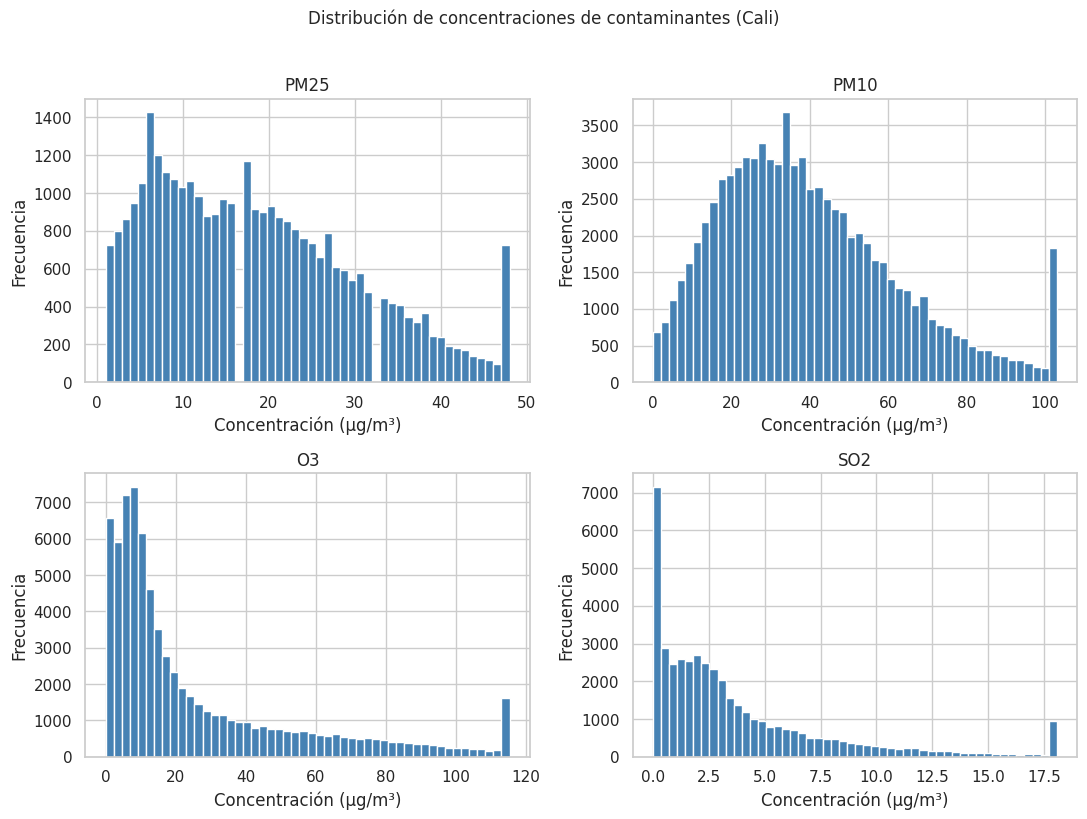

In [22]:
contaminantes = ['pm25', 'pm10', 'o3', 'so2']
sub = df[df['variable'].isin(contaminantes) & df['medicion'].notna() & (df['medicion'] >= 0)]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()
for i, v in enumerate(contaminantes):
    datos = sub[sub['variable'] == v]['medicion']
    axes[i].hist(datos.clip(upper=datos.quantile(0.98)), bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(v.upper())
    axes[i].set_xlabel('Concentración (µg/m³)')
    axes[i].set_ylabel('Frecuencia')
plt.suptitle('Distribución de concentraciones de contaminantes (Cali)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Las distribuciones de PM2.5, PM10, O3 y SO2 muestran la frecuencia con que se observa cada nivel de concentración. En general, la mayor parte de las mediciones se concentra en valores bajos o moderados, con colas hacia valores altos que corresponden a episodios de mayor contaminación. La forma de cada histograma ayuda a ver la variabilidad típica y la presencia de picos que superan los umbrales de la OMS; los contaminantes con colas más largas hacia la derecha son aquellos en los que los episodios perjudiciales aparecen con más frecuencia en los datos.

### 1.5.2. Superación de umbrales OMS por contaminante

variable  total  superan  % superan
    PM25  32702    17677      54.05
    PM10  82512    29110      35.28
      O3  74398     2829       3.80
     SO2  44151      124       0.28


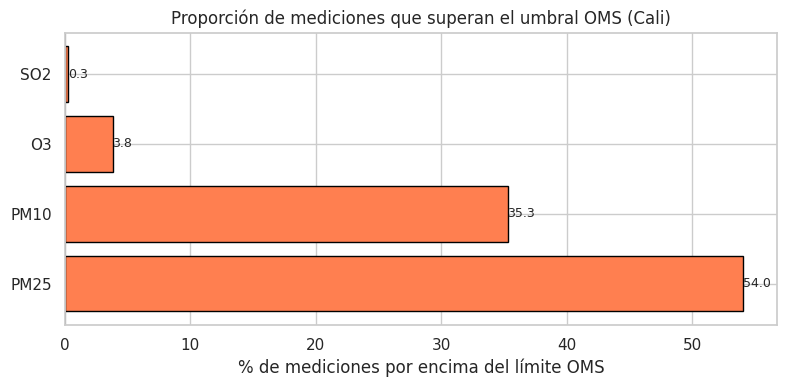

In [23]:
# Umbrales OMS (media 24h o 8h según contaminante)
umbrales = {'pm25': 15, 'pm10': 45, 'o3': 100, 'so2': 40}

resultados = []
for v in umbrales:
    sub = df[(df['variable'] == v) & df['medicion'].notna() & (df['medicion'] >= 0)]
    total = len(sub)
    superan = (sub['medicion'] > umbrales[v]).sum()
    pct = (superan / total * 100) if total > 0 else 0
    resultados.append({'variable': v.upper(), 'total': total, 'superan': superan, '% superan': round(pct, 2)})

tabla = pd.DataFrame(resultados)
print(tabla.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(tabla['variable'], tabla['% superan'], color='coral', edgecolor='black')
ax.axvline(x=0, color='gray', ls='-')
ax.set_xlabel('% de mediciones por encima del límite OMS')
ax.set_title('Proporción de mediciones que superan el umbral OMS (Cali)')
etiquetar_barras(ax, vertical=False, fmt='.1f')
plt.tight_layout()
plt.show()

El gráfico y la tabla muestran qué proporción de mediciones de cada contaminante supera el límite recomendado por la OMS. Un porcentaje alto indica que en Cali se registran con frecuencia niveles que pueden ser perjudiciales para ese contaminante; un porcentaje bajo no descarta picos puntuales en ciertas estaciones o fechas. Este resumen permite priorizar qué contaminantes y qué zonas o periodos conviene analizar con más detalle para proponer medidas o alertas.

### 1.5.3. Niveles por estación de monitoreo

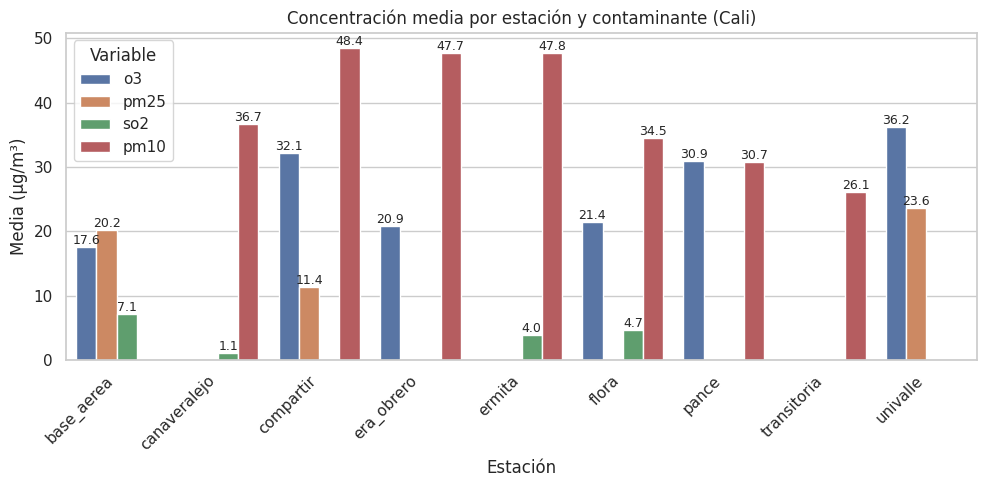

In [24]:
contaminantes = ['pm25', 'pm10', 'o3', 'so2']
sub = df[df['variable'].isin(contaminantes) & df['medicion'].notna() & (df['medicion'] >= 0)]

por_estacion = sub.groupby(['estacion', 'variable'])['medicion'].agg(['mean', 'count', 'max']).reset_index()
por_estacion = por_estacion[por_estacion['count'] >= 100]  # Solo estaciones con suficientes datos

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=por_estacion, x='estacion', y='mean', hue='variable', ax=ax)
ax.set_title('Concentración media por estación y contaminante (Cali)')
ax.set_ylabel('Media (µg/m³)')
ax.set_xlabel('Estación')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Variable')
etiquetar_barras(ax, vertical=True, fmt='.1f')
plt.tight_layout()
plt.show()

La concentración media por estación y contaminante permite identificar **puntos de la ciudad donde la contaminación es más alta**. Las estaciones con medias claramente por encima del umbral OMS (por ejemplo PM2.5 > 15 o PM10 > 45) son candidatas a zonas de mayor riesgo o a horarios o épocas con episodios frecuentes. Las diferencias entre estaciones pueden deberse al tráfico, la industria, la geografía o la densidad urbana; este EDA no establece causas, pero sí señala dónde los niveles alcanzan o superan límites que pueden ser perjudiciales.

### 1.5.4. Episodios de alta contaminación (máximos por estación)

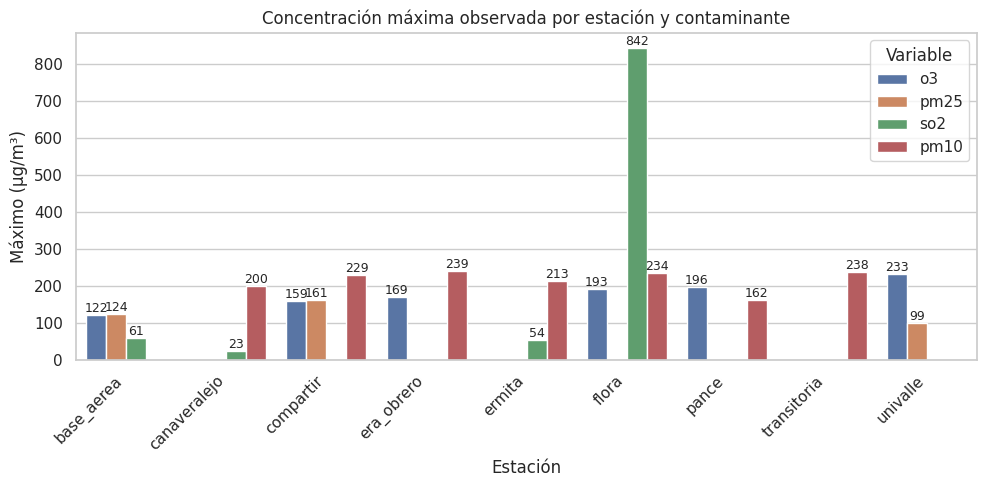

Estaciones y fechas con máximos más altos (ejemplo PM2.5):
                    fecha   estacion  medicion
2017-01-01 00:59:59+00:00  compartir     161.0
2017-01-01 01:59:59+00:00  compartir     147.0
2018-03-24 20:59:59+00:00 base_aerea     124.0
2018-01-01 01:59:59+00:00 base_aerea     120.0
2017-08-17 15:59:59+00:00 base_aerea     107.0


In [25]:
umbrales = {'pm25': 15, 'pm10': 45, 'o3': 100, 'so2': 40}
sub = df[df['variable'].isin(umbrales) & df['medicion'].notna() & (df['medicion'] >= 0)]
maximos = sub.groupby(['estacion', 'variable'])['medicion'].max().reset_index()
maximos['umbral'] = maximos['variable'].map(umbrales)
maximos['supera_umbral'] = maximos['medicion'] > maximos['umbral']

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=maximos, x='estacion', y='medicion', hue='variable', ax=ax)
ax.set_title('Concentración máxima observada por estación y contaminante')
ax.set_ylabel('Máximo (µg/m³)')
ax.set_xlabel('Estación')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Variable')
etiquetar_barras(ax, vertical=True, fmt='.0f')
plt.tight_layout()
plt.show()

print('Estaciones y fechas con máximos más altos (ejemplo PM2.5):')
pm = df[(df['variable']=='pm25') & df['medicion'].notna()].sort_values('medicion', ascending=False).head(5)
print(pm[['fecha', 'estacion', 'medicion']].to_string(index=False))

Los máximos por estación muestran los **picos de contaminación** registrados en cada punto. Donde el máximo está muy por encima del umbral OMS se han dado episodios que pueden ser perjudiciales para la salud. La tabla de ejemplo (PM2.5) indica en qué fechas y estaciones se alcanzaron los valores más altos; un análisis similar para PM10, O3 y SO2 permite localizar episodios críticos en tiempo y espacio para priorizar alertas o políticas en esas zonas o periodos.

## 1.6. Conclusiones del EDA

### 1.5.5. Mapa de calor: concentración media por estación y contaminante

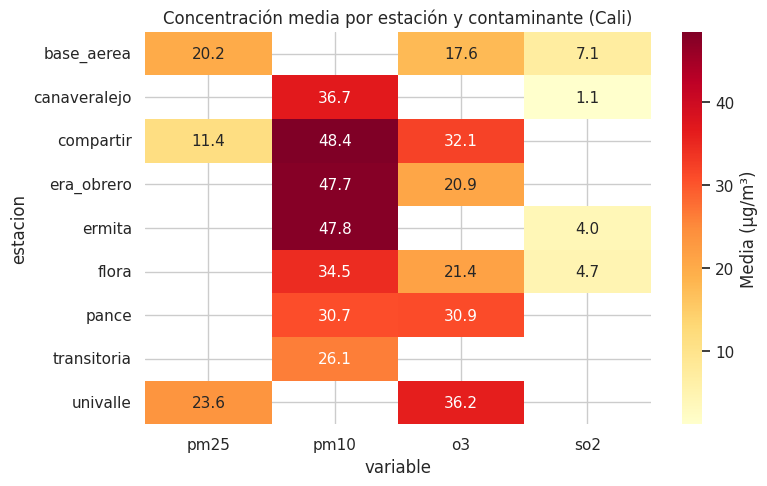

In [26]:
contaminantes = ['pm25', 'pm10', 'o3', 'so2']
sub = df[df['variable'].isin(contaminantes) & df['medicion'].notna() & (df['medicion'] >= 0)]
matriz = sub.pivot_table(index='estacion', columns='variable', values='medicion', aggfunc='mean')
matriz = matriz.reindex(columns=contaminantes)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(matriz, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Media (µg/m³)'})
ax.set_title('Concentración media por estación y contaminante (Cali)')
plt.tight_layout()
plt.show()

El mapa de calor permite comparar de un vistazo todas las combinaciones estación–contaminante. Las celdas más oscuras (tonos rojos) indican mayores concentraciones medias y señalan **puntos prioritarios** donde la calidad del aire es peor. Cruzar esta vista con los umbrales OMS (por ejemplo, PM2.5 > 15 o PM10 > 45) ayuda a identificar qué estaciones requieren atención en un plan de acción.

### 1.5.6. Evolución temporal: media mensual de PM2.5 y PM10

/tmp/ipykernel_44076/3259356460.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  sub['mes'] = sub['fecha'].dt.to_period('M')


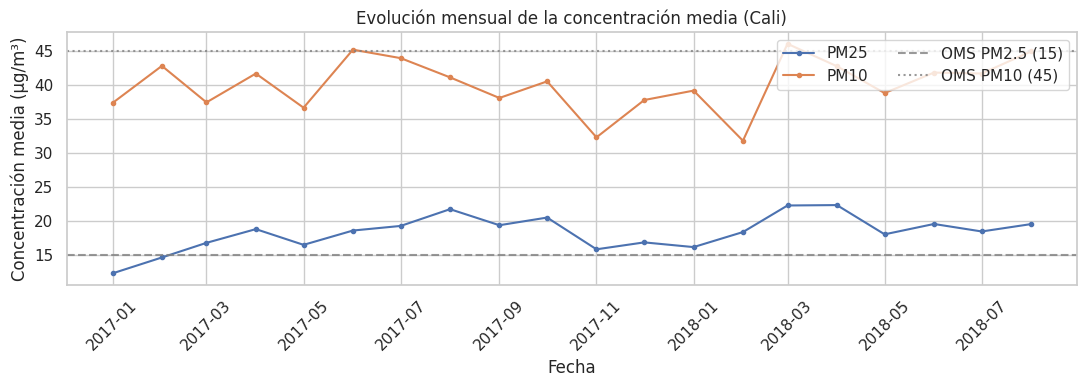

In [27]:
sub = df[df['variable'].isin(['pm25', 'pm10']) & df['medicion'].notna() & (df['medicion'] >= 0)].copy()
sub['mes'] = sub['fecha'].dt.to_period('M')
mensual = sub.groupby(['mes', 'variable'])['medicion'].mean().reset_index()
mensual['mes'] = mensual['mes'].apply(lambda p: p.to_timestamp() if hasattr(p, 'to_timestamp') else p)
fig, ax = plt.subplots(figsize=(11, 4))
for v in ['pm25', 'pm10']:
    datos = mensual[mensual['variable'] == v]
    ax.plot(datos['mes'], datos['medicion'], marker='o', markersize=3, label=v.upper())
ax.axhline(y=15, color='gray', linestyle='--', alpha=0.8, label='OMS PM2.5 (15)')
ax.axhline(y=45, color='gray', linestyle=':', alpha=0.8, label='OMS PM10 (45)')
ax.set_ylabel('Concentración media (µg/m³)')
ax.set_xlabel('Fecha')
ax.set_title('Evolución mensual de la concentración media (Cali)')
ax.legend(loc='upper right', ncol=2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La serie temporal muestra si la contaminación presenta **estacionalidad** o tendencia a lo largo de los años. Periodos en los que la media mensual supera las líneas de referencia OMS (discontinuas) corresponden a épocas con mayor riesgo para la salud; eso permite orientar el plan de acción hacia campañas o medidas en meses concretos (por ejemplo, episodios por quemas o por condiciones meteorológicas).

### 1.5.7. Distribución por estación: boxplot de PM2.5

/tmp/ipykernel_44076/2185228259.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pm25, x='estacion', y='medicion', order=orden, palette='Blues', ax=ax)


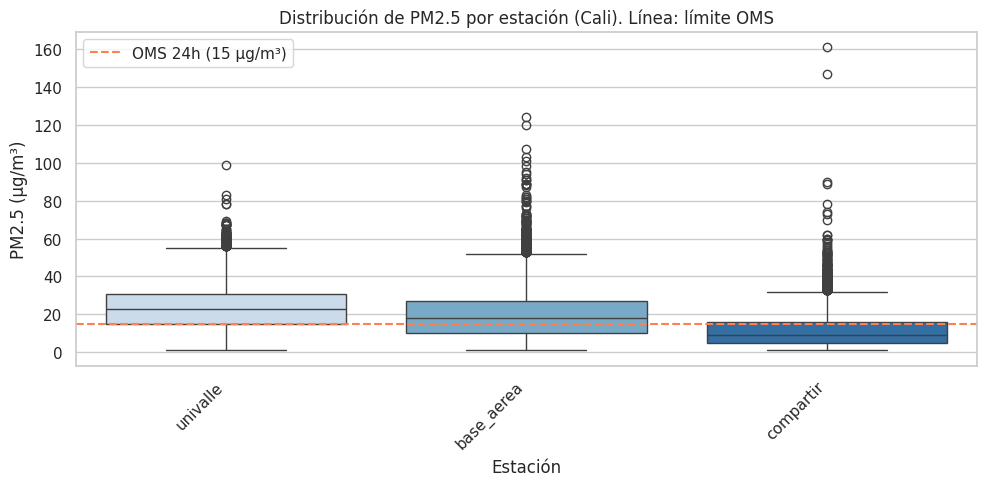

In [28]:
pm25 = df[(df['variable'] == 'pm25') & df['medicion'].notna() & (df['medicion'] >= 0)]
orden = pm25.groupby('estacion')['medicion'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=pm25, x='estacion', y='medicion', order=orden, palette='Blues', ax=ax)
ax.axhline(y=15, color='coral', linestyle='--', linewidth=1.5, label='OMS 24h (15 µg/m³)')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_xlabel('Estación')
ax.set_title('Distribución de PM2.5 por estación (Cali). Línea: límite OMS')
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

El boxplot muestra la distribución (mediana, cuartiles y valores atípicos) de PM2.5 en cada estación. Las estaciones cuya caja o bigotes rebasan la línea del umbral OMS son aquellas donde **con frecuencia se registran concentraciones no saludables**; los puntos por encima del bigote superior son episodios extremos. Esta vista complementa las medias y ayuda a priorizar zonas para el plan de acción según la proporción de mediciones altas y la magnitud de los picos.

### 1.5.8. Relación entre PM2.5 y PM10 (dispersión)

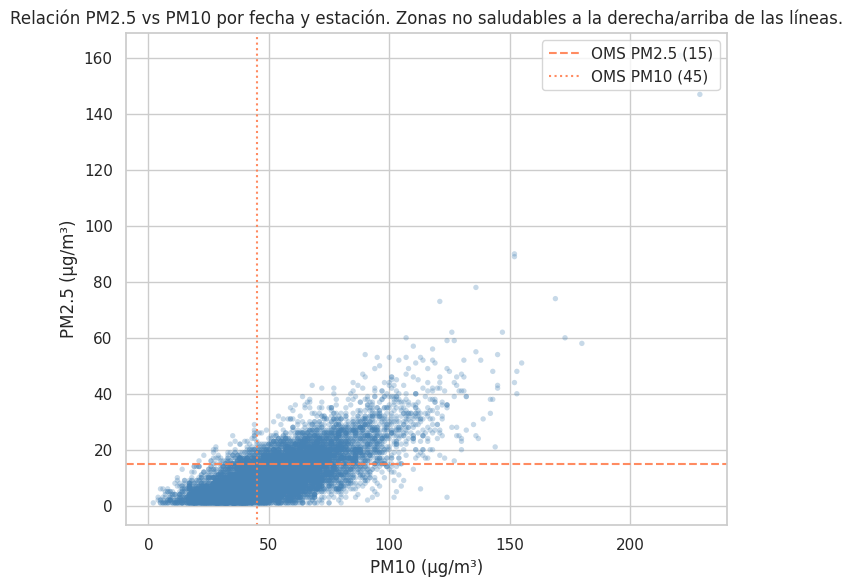

In [29]:
pm = df[df['variable'].isin(['pm25', 'pm10']) & df['medicion'].notna() & (df['medicion'] >= 0)]
pivot = pm.pivot_table(index=['fecha', 'estacion'], columns='variable', values='medicion').reset_index()
pivot = pivot.dropna()
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pivot['pm10'], pivot['pm25'], alpha=0.3, s=15, c='steelblue', edgecolors='none')
ax.axhline(y=15, color='coral', linestyle='--', alpha=0.9, label='OMS PM2.5 (15)')
ax.axvline(x=45, color='coral', linestyle=':', alpha=0.9, label='OMS PM10 (45)')
ax.set_xlabel('PM10 (µg/m³)')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('Relación PM2.5 vs PM10 por fecha y estación. Zonas no saludables a la derecha/arriba de las líneas.')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

El diagrama de dispersión muestra la relación entre PM10 y PM2.5 en las mismas fecha y estación. Los puntos que quedan **a la derecha de la línea vertical (PM10 > 45) o por encima de la horizontal (PM2.5 > 15)** corresponden a situaciones con concentraciones no saludables según la OMS. La nube de puntos y su correlación ayudan a entender si ambos contaminantes suben juntos (por ejemplo por una misma fuente) y cuántos episodios conjuntos de mala calidad del aire se registran.

### 1.5.9. Priorización para plan de acción: superaciones del umbral OMS por estación

/tmp/ipykernel_44076/1012926322.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['supera'] = sub.apply(lambda r: r['medicion'] > umbrales[r['variable']], axis=1)


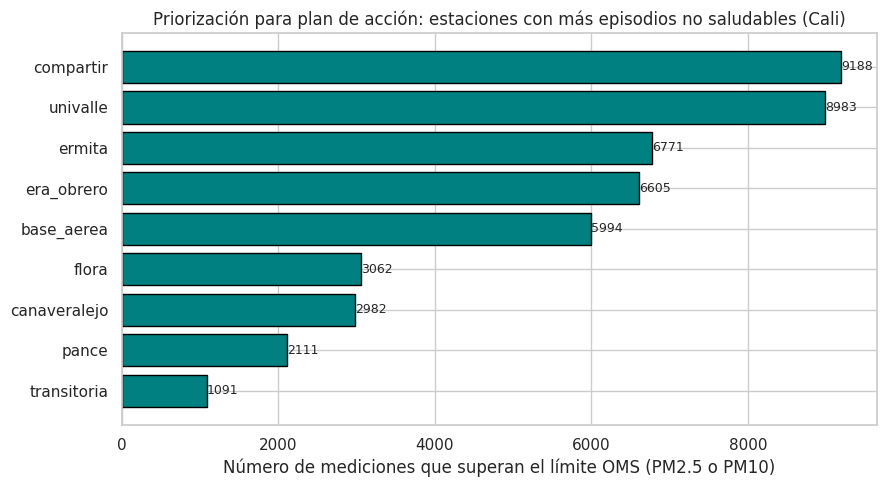

In [30]:
umbrales = {'pm25': 15, 'pm10': 45}
sub = df[df['variable'].isin(umbrales) & df['medicion'].notna() & (df['medicion'] >= 0)]
sub['supera'] = sub.apply(lambda r: r['medicion'] > umbrales[r['variable']], axis=1)
por_estacion = sub.groupby('estacion')['supera'].sum().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(por_estacion.index, por_estacion.values, color='teal', edgecolor='black')
ax.set_xlabel('Número de mediciones que superan el límite OMS (PM2.5 o PM10)')
ax.set_title('Priorización para plan de acción: estaciones con más episodios no saludables (Cali)')
etiquetar_barras(ax, vertical=False, fmt='.0f')
plt.tight_layout()
plt.show()

Esta gráfica resume **cuántas mediciones por estación superan el umbral OMS** (PM2.5 > 15 o PM10 > 45). Las estaciones con mayor número en la barra son candidatas prioritarias para el plan de acción: refuerzo del monitoreo, alertas a la población o medidas de reducción de emisiones en esa zona. El valor numérico sobre cada barra facilita la lectura y la comparación directa entre estaciones.

### 1.5.10. Porcentaje de mediciones no saludables (PM2.5) por estación

/tmp/ipykernel_44076/15989588.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pm25['supera_oms'] = pm25['medicion'] > 15


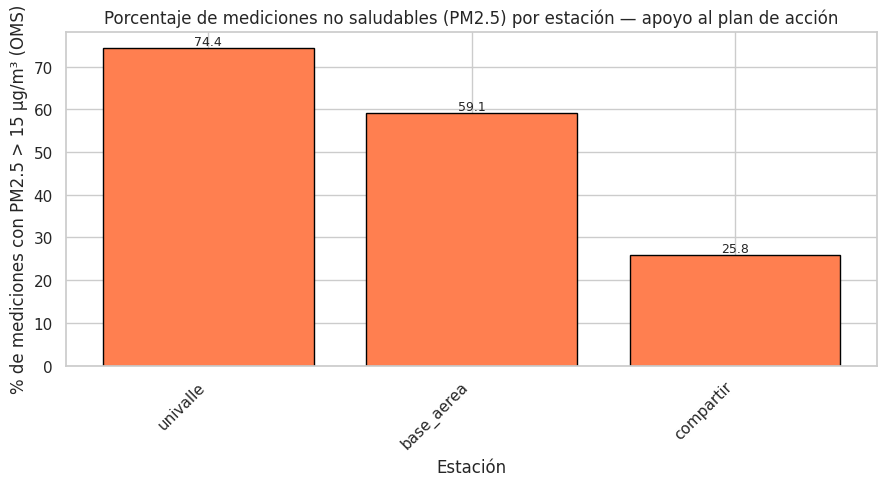

In [31]:
pm25 = df[(df['variable'] == 'pm25') & df['medicion'].notna() & (df['medicion'] >= 0)]
pm25['supera_oms'] = pm25['medicion'] > 15
pct_estacion = pm25.groupby('estacion').agg(total=('medicion', 'count'), superan=('supera_oms', 'sum')).assign(
    pct=lambda x: (x['superan'] / x['total'] * 100).round(1)).sort_values('pct', ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(pct_estacion.index, pct_estacion['pct'], color='coral', edgecolor='black')
ax.set_ylabel('% de mediciones con PM2.5 > 15 µg/m³ (OMS)')
ax.set_xlabel('Estación')
ax.set_title('Porcentaje de mediciones no saludables (PM2.5) por estación — apoyo al plan de acción')
plt.xticks(rotation=45, ha='right')
etiquetar_barras(ax, vertical=True, fmt='.1f')
plt.tight_layout()
plt.show()

Esta vista complementa la priorización: no solo cuenta cuántas veces se supera el umbral, sino **qué proporción de las mediciones de cada estación es no saludable**. Una estación con pocas mediciones pero alto porcentaje también es relevante para el plan de acción. Los valores sobre cada barra permiten comparar de forma directa el riesgo relativo por zona.

## 1.6. Conclusiones del EDA

El análisis exploratorio del dataset de Cali (data_2017_2022 1(in).csv) aborda la calidad del aire desde **múltiples ángulos**: distribuciones de contaminantes, superación de umbrales OMS, comparación entre estaciones (medias, máximos, boxplots), evolución temporal mensual, relación entre PM2.5 y PM10, y priorización para un **plan de acción** (conteo y porcentaje de mediciones no saludables por estación). El conjunto permite **detectar zonas con concentración no saludable** —estaciones y periodos donde PM2.5, PM10, O3 o SO2 superan los límites recomendados por la OMS— y fundamentar decisiones: en qué estaciones reforzar monitoreo o alertas, en qué épocas concentrar medidas y qué contaminantes priorizar. Los valores numéricos sobre las barras y las distintas formas de visualización (histogramas, mapas de calor, series temporales, boxplots, dispersión) facilitan la lectura y la comunicación con actores involucrados en políticas de calidad del aire. Este EDA sirve como base para modelado predictivo, sistemas de alerta temprana o informes de seguimiento.